# 05 - Cell Type Annotation & Interpretation

This notebook assigns biological cell type labels to clusters from the PBMC scRNA-seq dataset using preregistered canonical markers and decision rules.

## 1. Setup

Brief notebook purpose - assign biological cell type labels to clusters.

In [19]:
# TODO: Import libraries (scanpy, pandas, numpy, matplotlib, seaborn)
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, dpi_save=100)

In [2]:
# TODO: Load config files and canonical markers
config_dir = Path('../config')

config_files = {
    'clustering': 'clustering.yaml',
    'markers': 'markers.yaml',
    'pipeline': 'pipeline.yaml',
    'qc': 'qc.yaml'
}

config = {}

for key, filename in config_files.items():
    with open(config_dir / filename) as f:
        config[key] = yaml.safe_load(f)

## 2. Load Data

Load clustered data and marker validation results.

In [3]:
# TODO: Load data/processed/adata_clustered.h5ad
adata = sc.read_h5ad('../data/processed/adata_clustered.h5ad')

In [4]:
# TODO: Load canonical marker validation table from Week 6
marker_table = pd.read_csv('../results/markers/canonical_marker_validation.csv')
print(marker_table)

   cluster                        detected_canonical_markers
0        0                  ['CD3D', 'CD3E', 'IL7R', 'CCR7']
1        1                       ['LST1', 'CD14', 'HLA-DRA']
2        2                     ['CD79A', 'HLA-DRA', 'MS4A1']
3        3        ['NKG7', 'GZMA', 'GNLY', 'FCGR3A', 'CD8A']
4        4  ['NKG7', 'GZMA', 'IL7R', 'CD3D', 'CD8A', 'CD3E']
5        5            ['LST1', 'FCGR3A', 'HLA-DRA', 'ITGAX']
6        6                               ['HLA-DRA', 'LST1']


In [5]:
# TODO: Verify resolution 1.0 clustering exists
'leiden_1_0' in adata.obs.columns

True

In [6]:
# TODO: Print cluster counts
print(f"Cluster Counts: {adata.obs['leiden_1_0'].value_counts().sort_index()}")

Cluster Counts: leiden_1_0
0    1181
1     477
2     357
3     288
4     198
5     182
6      36
Name: count, dtype: int64


## 3. Annotation Decision Matrix

Create mapping from clusters to cell types based on canonical markers.

Document reasoning for each annotation.

In [7]:
# TODO: Create annotation dictionary mapping cluster → cell type
annotation_dict = {
    '0': 'Naive CD4+ T cells',
    '1': 'CD14+ Monocytes', 
    '2': 'B cells',
    '3': 'NK cells',
    '4': 'CD8+ T cells',
    '5': 'Dendritic cells',
    '6': 'Uncertain myeloid'
}

In [8]:
# TODO: For each cluster, document which canonical markers support the label
annotation_evidence = {
    '0': ['CD3D', 'CD3E', 'IL7R', 'CCR7'],
    '1': ['CD14', 'HLA-DRA', 'LST1'],
    '2': ['MS4A1', 'CD79A', 'HLA-DRA'],
    '3': ['GNLY', 'NKG7', 'GZMA', 'FCGR3A'],
    '4': ['CD3D', 'CD3E', 'CD8A', 'GZMA', 'NKG7'],
    '5': ['ITGAX', 'HLA-DRA', 'FCGR3A', 'LST1'],
    '6': ['HLA-DRA', 'LST1']  
}

In [9]:
# TODO: Flag Cluster 6 as 'Uncertain myeloid' due to borderline markers
print(f"Cluster 6 annotation: {annotation_dict['6']}")
print(f"Markers: {annotation_evidence['6']} (borderline: only 2 shared markers)")

Cluster 6 annotation: Uncertain myeloid
Markers: ['HLA-DRA', 'LST1'] (borderline: only 2 shared markers)


## 4. Apply Annotations

Add cell type labels to AnnData object.

In [10]:
# TODO: Create new column 'cell_type' in adata.obs
# TODO: Map leiden_1.0 clusters to cell_type labels using annotation dict
adata.obs['cell_type'] = adata.obs['leiden_1_0'].map(annotation_dict)

In [11]:
# TODO: Verify all clusters have labels
adata.obs['cell_type'].isna().sum()

0

In [12]:
# TODO: Print value_counts of cell types
adata.obs['cell_type'].value_counts()

cell_type
Naive CD4+ T cells    1181
CD14+ Monocytes        477
B cells                357
NK cells               288
CD8+ T cells           198
Dendritic cells        182
Uncertain myeloid       36
Name: count, dtype: int64

## 5. Annotation Quality Assessment

Verify annotations against marker evidence.

In [13]:
# Load canonical marker validation from Week 6
canonical_validation = pd.read_csv('../results/markers/canonical_marker_validation.csv')
print(canonical_validation.columns)
print(canonical_validation.head())

Index(['cluster', 'detected_canonical_markers'], dtype='object')
   cluster                        detected_canonical_markers
0        0                  ['CD3D', 'CD3E', 'IL7R', 'CCR7']
1        1                       ['LST1', 'CD14', 'HLA-DRA']
2        2                     ['CD79A', 'HLA-DRA', 'MS4A1']
3        3        ['NKG7', 'GZMA', 'GNLY', 'FCGR3A', 'CD8A']
4        4  ['NKG7', 'GZMA', 'IL7R', 'CD3D', 'CD8A', 'CD3E']


In [14]:
# TODO: For each cell type, print top 5 canonical markers found

for cluster_id in sorted(adata.obs['leiden_1_0'].unique()):
    cell_type = annotation_dict[cluster_id]
    
    cluster_markers = canonical_validation[canonical_validation['cluster'] == int(cluster_id)]
    canonical_found = cluster_markers['detected_canonical_markers'].tolist()[:5] 
    
    print(f"{cell_type} (Cluster {cluster_id}): {canonical_found}")

Naive CD4+ T cells (Cluster 0): ["['CD3D', 'CD3E', 'IL7R', 'CCR7']"]
CD14+ Monocytes (Cluster 1): ["['LST1', 'CD14', 'HLA-DRA']"]
B cells (Cluster 2): ["['CD79A', 'HLA-DRA', 'MS4A1']"]
NK cells (Cluster 3): ["['NKG7', 'GZMA', 'GNLY', 'FCGR3A', 'CD8A']"]
CD8+ T cells (Cluster 4): ["['NKG7', 'GZMA', 'IL7R', 'CD3D', 'CD8A', 'CD3E']"]
Dendritic cells (Cluster 5): ["['LST1', 'FCGR3A', 'HLA-DRA', 'ITGAX']"]
Uncertain myeloid (Cluster 6): ["['HLA-DRA', 'LST1']"]


In [15]:
# TODO: Calculate proportion of cells in each annotated type
cell_type_counts = adata.obs['cell_type'].value_counts()
cell_type_props = (cell_type_counts / len(adata) * 100).round(2)
print("Cell type proportions:")
print(pd.DataFrame({'Count': cell_type_counts, 'Proportion (%)': cell_type_props}))

Cell type proportions:
                    Count  Proportion (%)
cell_type                                
Naive CD4+ T cells   1181           43.44
CD14+ Monocytes       477           17.54
B cells               357           13.13
NK cells              288           10.59
CD8+ T cells          198            7.28
Dendritic cells       182            6.69
Uncertain myeloid      36            1.32


In [16]:
# TODO: Identify which annotations are high-confidence vs uncertain
high_confidence = [ct for cluster_id, ct in annotation_dict.items() 
                   if len(annotation_evidence[cluster_id]) >= 4]
moderate_confidence = [ct for cluster_id, ct in annotation_dict.items() 
                       if len(annotation_evidence[cluster_id]) == 3]
low_confidence = [ct for cluster_id, ct in annotation_dict.items() 
                  if len(annotation_evidence[cluster_id]) <= 2]

print(f"\nHigh confidence (≥4 markers): {high_confidence}")
print(f"Moderate confidence (3 markers): {moderate_confidence}")
print(f"Low confidence (≤2 markers): {low_confidence}")


High confidence (≥4 markers): ['Naive CD4+ T cells', 'NK cells', 'CD8+ T cells', 'Dendritic cells']
Moderate confidence (3 markers): ['CD14+ Monocytes', 'B cells']
Low confidence (≤2 markers): ['Uncertain myeloid']


## 6. Visualizations

Generate annotated UMAPs and marker expression plots.

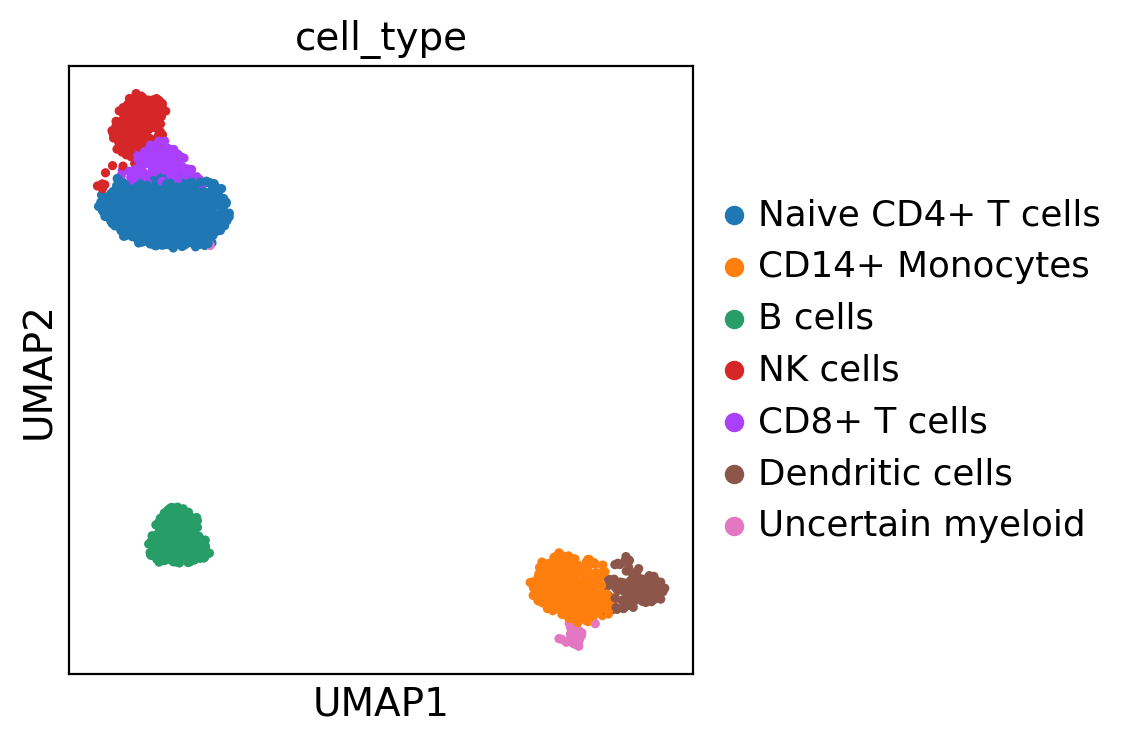

In [20]:
# TODO: Plot UMAP colored by cell_type (primary figure)
# TODO: Save to results/clustering/figures/umap_annotated.png
sc.pl.umap(adata, color='cell_type', save='umap_cell_type.png')   

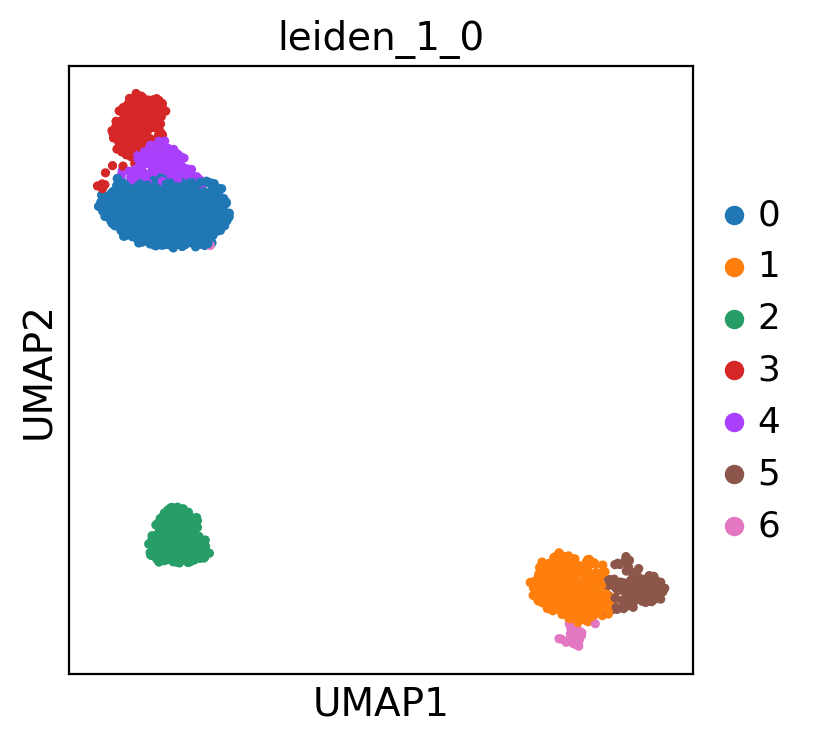

In [21]:
# TODO: Plot UMAP colored by leiden_1.0 (for comparison)
sc.pl.umap(adata, color='leiden_1_0')

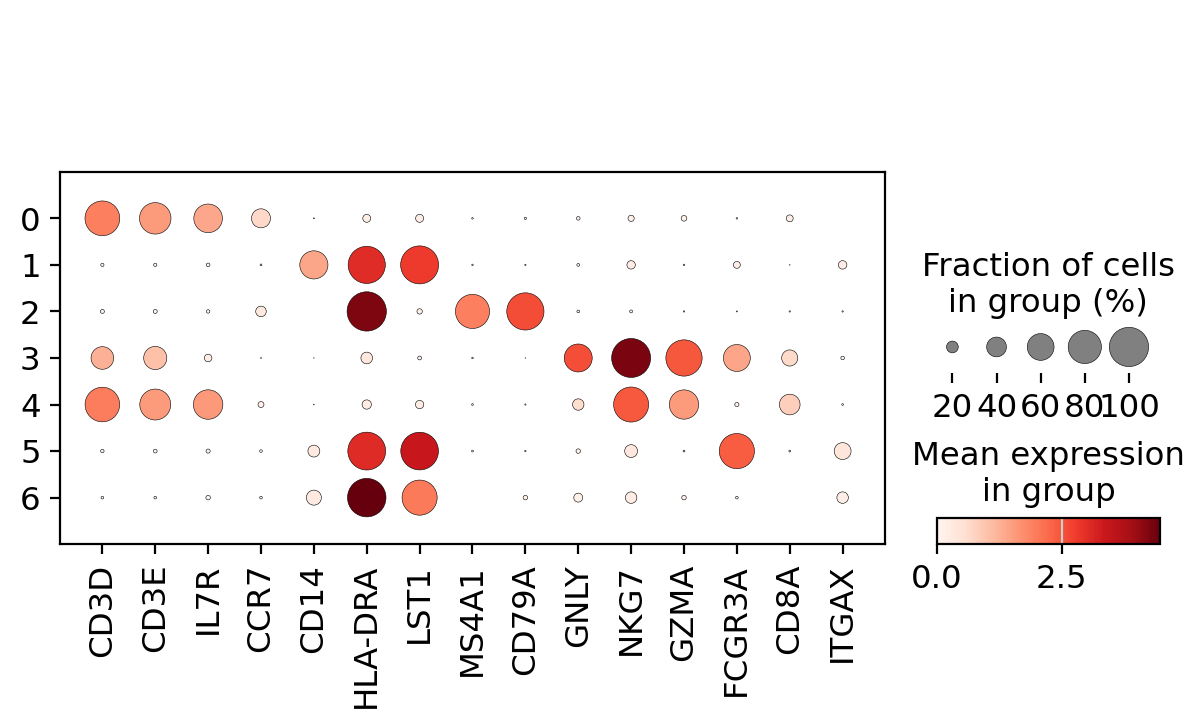

In [28]:
# TODO: Create dotplot showing canonical markers per cell type
# TODO: Save to results/markers/figures/canonical_markers_dotplot.png
all_canonical_markers = []
for cluster_id in annotation_evidence.keys():
    all_canonical_markers.extend(annotation_evidence[cluster_id])

all_canonical_markers = list(dict.fromkeys(all_canonical_markers))

sc.pl.dotplot(adata, all_canonical_markers, groupby='leiden_1_0', save='canonical_markers_dotplot.png')

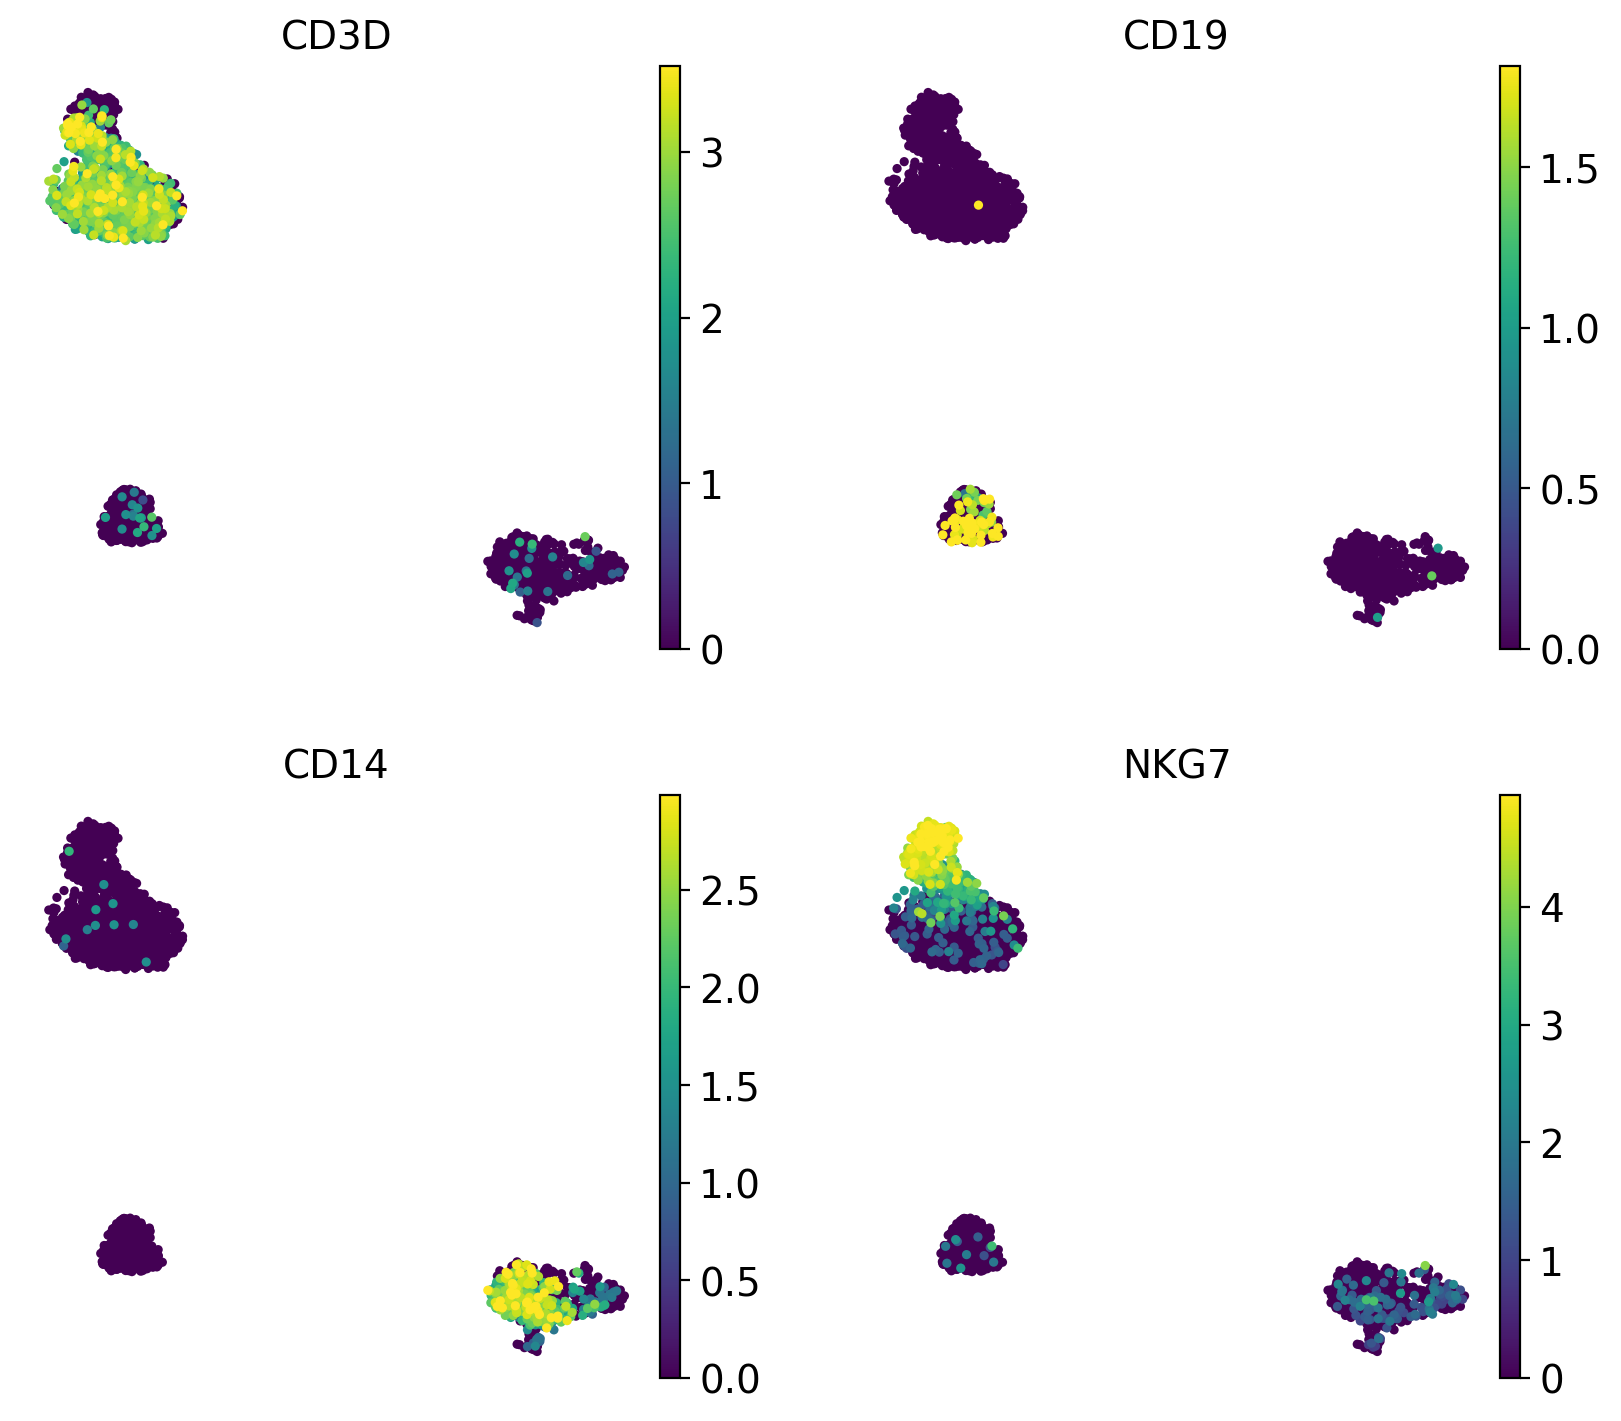

In [29]:
# TODO: Create feature plots for key markers (CD3D, CD19, CD14, NKG7)
key_markers = ['CD3D', 'CD19', 'CD14', 'NKG7']
sc.pl.umap(adata, color=key_markers, ncols=2, cmap='viridis', vmin=0, vmax='p99', frameon=False)

## 7. Cluster-to-Cell-Type Mapping Table

Generate final summary table for reporting.

In [30]:
# Create mapping table with cluster annotations, counts, and confidence levels
mapping_table = pd.DataFrame({
    'Cluster': sorted(annotation_dict.keys()),
    'Cell Type': [annotation_dict[c] for c in sorted(annotation_dict.keys())],
    'Cell Count': [cell_type_counts.get(annotation_dict[c], 0) for c in sorted(annotation_dict.keys())],
    'Proportion (%)': [cell_type_props.get(annotation_dict[c], 0) for c in sorted(annotation_dict.keys())],
    'Canonical Markers': [', '.join(annotation_evidence[c]) for c in sorted(annotation_dict.keys())],
    'Confidence': ['High' if annotation_dict[c] in high_confidence 
                   else 'Moderate' if annotation_dict[c] in moderate_confidence 
                   else 'Low' for c in sorted(annotation_dict.keys())]
})

print(mapping_table)

  Cluster           Cell Type  Cell Count  Proportion (%)  \
0       0  Naive CD4+ T cells        1181           43.44   
1       1     CD14+ Monocytes         477           17.54   
2       2             B cells         357           13.13   
3       3            NK cells         288           10.59   
4       4        CD8+ T cells         198            7.28   
5       5     Dendritic cells         182            6.69   
6       6   Uncertain myeloid          36            1.32   

              Canonical Markers Confidence  
0        CD3D, CD3E, IL7R, CCR7       High  
1           CD14, HLA-DRA, LST1   Moderate  
2         MS4A1, CD79A, HLA-DRA   Moderate  
3      GNLY, NKG7, GZMA, FCGR3A       High  
4  CD3D, CD3E, CD8A, GZMA, NKG7       High  
5  ITGAX, HLA-DRA, FCGR3A, LST1       High  
6                 HLA-DRA, LST1        Low  


In [31]:
marker_counts = {cluster: len(markers) for cluster, markers in annotation_evidence.items()}
evidence_strength = {
    cluster: 'High' if count >= 4 else 'Moderate' if count == 3 else 'Low'
    for cluster, count in marker_counts.items()
}

marker_summary = pd.DataFrame({
    'Cluster': sorted(annotation_dict.keys(), key=int),
    'Cell Type': [annotation_dict[c] for c in sorted(annotation_dict.keys(), key=int)],
    'Marker Count': [marker_counts[c] for c in sorted(annotation_dict.keys(), key=int)],
    'Evidence Strength': [evidence_strength[c] for c in sorted(annotation_dict.keys(), key=int)],
    'Canonical Markers': [', '.join(annotation_evidence[c]) for c in sorted(annotation_dict.keys(), key=int)]
})

print(marker_summary)

  Cluster           Cell Type  Marker Count Evidence Strength  \
0       0  Naive CD4+ T cells             4              High   
1       1     CD14+ Monocytes             3          Moderate   
2       2             B cells             3          Moderate   
3       3            NK cells             4              High   
4       4        CD8+ T cells             5              High   
5       5     Dendritic cells             4              High   
6       6   Uncertain myeloid             2               Low   

              Canonical Markers  
0        CD3D, CD3E, IL7R, CCR7  
1           CD14, HLA-DRA, LST1  
2         MS4A1, CD79A, HLA-DRA  
3      GNLY, NKG7, GZMA, FCGR3A  
4  CD3D, CD3E, CD8A, GZMA, NKG7  
5  ITGAX, HLA-DRA, FCGR3A, LST1  
6                 HLA-DRA, LST1  


In [33]:
# TODO: Save to results/annotation/cluster_celltype_mapping.csv
import os
directory = "../results/annotation"
os.makedirs(directory, exist_ok=True)
marker_summary.to_csv('../results/annotation/cluster_celltype_mapping.csv')

In [34]:
# TODO: Display formatted table
marker_summary

,Cluster,Cell Type,Marker Count,Evidence Strength,Canonical Markers
0,0,Naive CD4+ T cells,4,High,"CD3D, CD3E, IL7R, CCR7"
1,1,CD14+ Monocytes,3,Moderate,"CD14, HLA-DRA, LST1"
2,2,B cells,3,Moderate,"MS4A1, CD79A, HLA-DRA"
3,3,NK cells,4,High,"GNLY, NKG7, GZMA, FCGR3A"
4,4,CD8+ T cells,5,High,"CD3D, CD3E, CD8A, GZMA, NKG7"
5,5,Dendritic cells,4,High,"ITGAX, HLA-DRA, FCGR3A, LST1"
6,6,Uncertain myeloid,2,Low,"HLA-DRA, LST1"


## 8. Limitations & Uncertainty Documentation

Explicitly document annotation limitations and uncertainties.

### Known limitations

In [35]:
# TODO: Document NK/CD8+ T marker overlap (Clusters 3-4)
print("1. NK cells vs CD8+ T cells (Clusters 3-4):")
print("   Both populations express cytotoxic markers (NKG7, GZMA).")
print("   Distinction based on CD3 complex: Cluster 3 lacks CD3D/CD3E (NK),")
print("   Cluster 4 has CD3D/CD3E/CD8A (CD8+ T). This is biologically expected.")
print()

1. NK cells vs CD8+ T cells (Clusters 3-4):
   Both populations express cytotoxic markers (NKG7, GZMA).
   Distinction based on CD3 complex: Cluster 3 lacks CD3D/CD3E (NK),
   Cluster 4 has CD3D/CD3E/CD8A (CD8+ T). This is biologically expected.



In [36]:
# TODO: Document Cluster 6 borderline annotation (only 2 shared markers)
print("2. Cluster 6 (Uncertain myeloid):")
print("   Only 2 canonical markers detected (HLA-DRA, LST1), both shared")
print("   across monocytes, dendritic cells, and other myeloid populations.")
print("   Insufficient evidence for specific subtype assignment.")
print()

2. Cluster 6 (Uncertain myeloid):
   Only 2 canonical markers detected (HLA-DRA, LST1), both shared
   across monocytes, dendritic cells, and other myeloid populations.
   Insufficient evidence for specific subtype assignment.



In [37]:
# TODO: Document lack of monocyte subtype resolution (CD14+ vs CD16+)
print("3. Monocyte subtype resolution:")
print("   Cluster 1 identified as CD14+ monocytes, but CD16+ (FCGR3A+)")
print("   monocytes not clearly resolved as separate cluster at resolution 1.0.")
print("   Higher resolution or targeted analysis may be needed for subtype discrimination.")
print()

3. Monocyte subtype resolution:
   Cluster 1 identified as CD14+ monocytes, but CD16+ (FCGR3A+)
   monocytes not clearly resolved as separate cluster at resolution 1.0.
   Higher resolution or targeted analysis may be needed for subtype discrimination.



In [38]:
# TODO: Document absence of rare populations (e.g., plasmablasts, basophils)
print("4. Rare cell populations:")
print("   No clusters identified as plasmablasts, basophils, mast cells,")
print("   or other rare PBMC populations (<1% frequency). These may be")
print("   under-represented in the 2,719-cell dataset or merged into")
print("   larger clusters at current resolution.")

4. Rare cell populations:
   No clusters identified as plasmablasts, basophils, mast cells,
   or other rare PBMC populations (<1% frequency). These may be
   under-represented in the 2,719-cell dataset or merged into
   larger clusters at current resolution.


### Uncertainty quantification

In [40]:
# TODO: List high-confidence annotations (≥4 canonical markers)
high_conf = []
for c in annotation_dict:
    if len(annotation_evidence[c]) >= 4:
        high_conf.append((annotation_dict[c], len(annotation_evidence[c])))

print(f"High confidence (≥4 markers): {[ct for ct, _ in high_conf]}")

High confidence (≥4 markers): ['Naive CD4+ T cells', 'NK cells', 'CD8+ T cells', 'Dendritic cells']


In [41]:
# TODO: List moderate-confidence annotations (3 markers)
mod_conf = []
for c in annotation_dict:
    if len(annotation_evidence[c]) == 3:
        mod_conf.append((annotation_dict[c], len(annotation_evidence[c])))

print(f"Moderate confidence (3 markers): {[ct for ct, _ in mod_conf]}")

Moderate confidence (3 markers): ['CD14+ Monocytes', 'B cells']


In [44]:
# TODO: List low-confidence annotations (2 markers, shared)
low_conf = []
for c in annotation_dict:
    if len(annotation_evidence[c]) <= 2:
        low_conf.append((annotation_dict[c], len(annotation_dict[c])))
    
print(f"Low confidence (< 2 markers): {[ct for ct, _ in low_conf]}")

Low confidence (< 2 markers): ['Uncertain myeloid']


### Alternative interpretations

In [45]:
# TODO: Document that Cluster 6 could be: DC subset, monocyte subset, or transitional state
print("Cluster 6 alternative interpretations:")
print("  - DC subset (shares HLA-DRA, LST1 with Cluster 5)")
print("  - Monocyte subset (shares markers with Cluster 1)")
print("  - Transitional/intermediate myeloid state")

Cluster 6 alternative interpretations:
  - DC subset (shares HLA-DRA, LST1 with Cluster 5)
  - Monocyte subset (shares markers with Cluster 1)
  - Transitional/intermediate myeloid state


In [46]:
# TODO: Document that higher resolution might split T cell subtypes further
print("\nPotential for higher resolution:")
print("  - T cells (Clusters 0, 4) may split into memory/effector subtypes")
print("  - Resolution 1.5 showed 8 clusters vs 7 at 1.0 (ARI=0.679)")


Potential for higher resolution:
  - T cells (Clusters 0, 4) may split into memory/effector subtypes
  - Resolution 1.5 showed 8 clusters vs 7 at 1.0 (ARI=0.679)


## 9. Success Criteria Evaluation

Evaluate against preregistered success criteria.

In [47]:
# TODO: Check: 6-15 clusters? (7 clusters ✓)
print("✓ Cluster count: 7 (within 6-15 range)")

✓ Cluster count: 7 (within 6-15 range)


In [48]:
# TODO: Check: Recovery of ≥4 major lineages? (T, B, NK, Mono, DC = 5 ✓)
lineages = ['T cells', 'B cells', 'NK cells', 'Monocytes', 'Dendritic cells']
print(f"✓ Major lineages recovered: {len(lineages)} (T, B, NK, Monocytes, DCs)")

✓ Major lineages recovered: 5 (T, B, NK, Monocytes, DCs)


In [49]:
# TODO: Check: No cluster defined by MT genes? (verified in Week 6 ✓)
print("✓ No MT-driven clusters (verified in Week 6 QC)")

✓ No MT-driven clusters (verified in Week 6 QC)


In [52]:
# TODO: Check: Stability across resolutions? (ARI 0.68-0.87, borderline ✓)
print("≈ Stability: ARI 0.866 (1.0 vs 0.5), ARI 0.679 (1.0 vs 1.5) - borderline")

≈ Stability: ARI 0.866 (1.0 vs 0.5), ARI 0.679 (1.0 vs 1.5) - borderline


In [53]:
# TODO: Check: <25% cell loss in QC? (1.2% loss ✓)
print("✓ QC cell loss: 1.2% (33/2752 cells removed, well below 25% threshold)")

✓ QC cell loss: 1.2% (33/2752 cells removed, well below 25% threshold)


In [54]:
# TODO: Document which criteria passed/failed
print("\nSummary:")
print("  PASSED: Cluster count, lineage recovery, MT check, QC loss")
print("  BORDERLINE: Resolution stability (ARI 0.679 below 0.7 threshold)")


Summary:
  PASSED: Cluster count, lineage recovery, MT check, QC loss
  BORDERLINE: Resolution stability (ARI 0.679 below 0.7 threshold)


## 10. Save Annotated Data

Save final annotated AnnData object.

In [55]:
# TODO: Save adata to data/processed/adata_annotated.h5ad
output_path = '../data/processed/adata_annotated.h5ad'
adata.write(output_path)

In [58]:
# TODO: Verify cell_type column exists in saved file
'cell_type' in adata.obs.columns

True

In [56]:
# TODO: Print output path and file size
size_mb = os.path.getsize(output_path) / (1024 ** 2)
print(f"Saved to: {output_path}")
print(f"File size: {size_mb:.2f} MB")

Saved to: ../data/processed/adata_annotated.h5ad
File size: 69.14 MB


## 11. Summary

Final summary of annotation results.

- State which major PBMC lineages were recovered
- State confidence levels for each annotation
- List limitations and uncertainties explicitly
- Prepare for Week 8 documentation and defense